### Domain Generlization in Classsification / Regression
- ERM (Empirical Risk Minimization)
- IRM (Invariant Risk Minimization)
- Fish (Inter Domain Gradient Matcing)


1. covariate shift 데이터 생성

In [1]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [2]:
# 필요한 라이브러리 임포트
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification, make_regression

# 도메인 수 및 샘플 수 설정
num_domains = 5
samples_per_domain = 200

In [3]:
# 분류용 데이터 생성
classification_data = []
for i in range(num_domains):
  X, y = make_classification(n_samples=samples_per_domain, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1, flip_y=0.1, random_state=42)# i
  X += np.array([i * 2.0, 0])  # x축 방향으로 shift
  # # 도메인마다 X의 분포를 다르게 하기 위해 shift 적용
  # if i%2==0:
  #   X += np.array([i * 2.0, 0])  # x축 방향으로 shift
  # else:
  #   X += np.array([0, i * 2.0])  # x축 방향으로 shift
  classification_data.append((X, y))

In [4]:
# 회귀용 데이터 생성
regression_data = []
for i in range(num_domains):
    X, y = make_regression(n_samples=samples_per_domain, n_features=2, noise=10.0, random_state=42)# i
    # 도메인마다 X의 분포를 다르게 하기 위해 shift 적용
    X += np.array([i * 2.0, 0])  # x축 방향으로 shift
    regression_data.append((X, y))


In [5]:
# 시각화 함수 정의
def plot_domains(data, task_type='classification'):
    plt.figure(figsize=(15, 3))
    for i, (X, y) in enumerate(data):
        plt.subplot(1, num_domains, i + 1)
        if task_type == 'classification':
            plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
        else:
            plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
        plt.title(f'Domain {i + 1}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

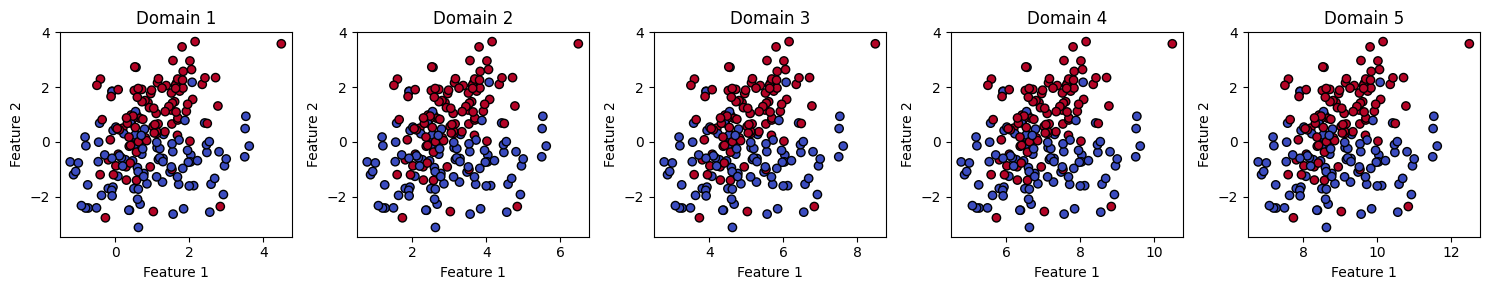

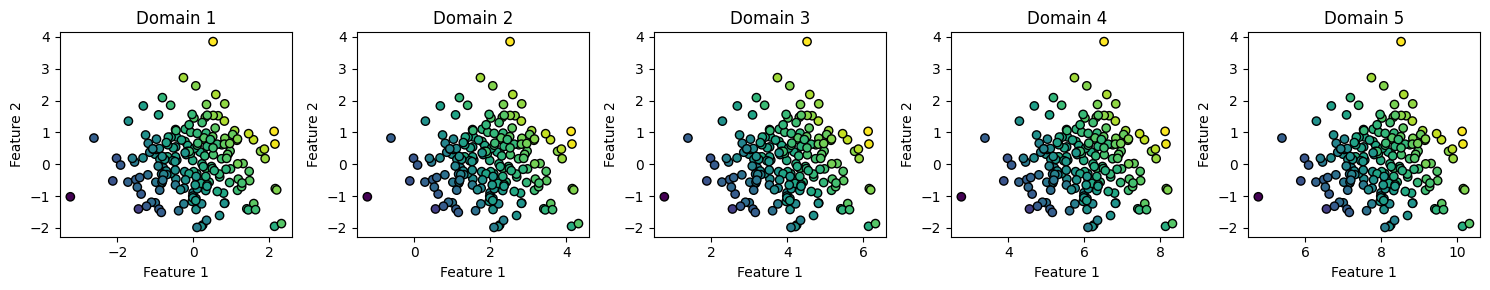

In [6]:
# 분류용 데이터 시각화
plot_domains(classification_data, task_type='classification')

# 회귀용 데이터 시각화
plot_domains(regression_data, task_type='regression')

2. 데이터 전처리: 학습/검증/테스트, 정규화, 텐서변환, Data Loader 준비

In [7]:
len(classification_data) # 도메인 1 X, Y

5

In [8]:
len(classification_data[0]) # 도메인 1 X, Y

2

In [9]:
classification_data[0][0].shape # X.shape

(200, 2)

In [10]:
len(classification_data[0])

2

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 학습 도메인: 도메인 1~4
train_domains = classification_data[:4] # domain 1~4
test_domain = classification_data[4] # domain 5

def convert_to_tensor_domains(domains, scaler=None):
    tensor_domains = []
    for X, y in domains:
        if scaler:
            X = scaler.transform(X)
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        tensor_domains.append((X_t, y_t))
    return tensor_domains

train_domains_tensor = convert_to_tensor_domains(classification_data[:4])
test_domain_tensor = convert_to_tensor_domains(classification_data[:4])


3. 모델링
- 분류용 및 회귀용 MLP 모델 정의
- ERM, IRM, Fish(IDGM) 비용 함수
- 학습 코드


In [12]:
import torch.nn as nn
import torch.nn.functional as F

# 분류용 MLP 모델
class ClassificationMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super(ClassificationMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

import torch.nn as nn
import torch.nn.functional as F

# 회귀용 MLP 모델
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super(RegressionMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 정확도 평가 함수 (공통)
def evaluate_accuracy(model, domains, model_name="Model"):
    model.eval()
    accs = []
    with torch.no_grad():
        for i, (X, y) in enumerate(domains):
            X_tensor = torch.tensor(X, dtype=torch.float32)
            y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
            pred = torch.sigmoid(model(X_tensor)) > 0.5
            acc = (pred == y_tensor).float().mean().item()
            accs.append(acc)
            print(f"{model_name} | Domain {i+1}: Accuracy = {acc:.4f}")
    return accs

In [13]:
# ERM 학습 함수
def train_erm(model, train_domains, criterion, lr=1e-3, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        for X, y in train_domains:
            X_t = torch.tensor(X, dtype=torch.float32)
            y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

            outputs = model(X_t)
            loss = criterion(outputs, y_t)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



In [14]:
# Fish 학습 함수
def dot_norm(g1, g2, eps=1e-8):
    return (g1 * g2).sum() / (g1.norm() * g2.norm() + eps)

def train_fish(model, train_domains, criterion, lr=1e-3, epochs=100, penalty_weight=1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        grads_by_domain, losses = [], []

        # 도메인 별 gradient 계산
        for X, y in train_domains:
            X_t = torch.tensor(X, dtype=torch.float32)
            y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
            out = model(X_t)
            loss = criterion(out, y_t)
            losses.append(loss)

            # dict 형태로 저장
            grad_dict = {}
            grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
            for (name, param), g in zip(model.named_parameters(), grads):
                grad_dict[name] = g
            grads_by_domain.append(grad_dict)

        # Gradient-Inner Product: domain 간 gradient 내적 계산
        penalty = 0.0
        num = len(grads_by_domain)
        for i in range(num):
            for j in range(i + 1, num):
                for key in grads_by_domain[i]:
                    g1 = grads_by_domain[i][key]
                    g2 = grads_by_domain[j][key]

                    penalty += dot_norm(g1, g2)

        total_loss = sum(losses) / len(losses) - penalty_weight * penalty

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()


In [15]:
# ERM 학습 및 평가
model_erm = ClassificationMLP()
criterion_erm = nn.BCEWithLogitsLoss()
train_erm(model_erm, train_domains, criterion_erm)
acc_erm = evaluate_accuracy(model_erm, classification_data, "ERM")
print("ERM acc_erm", acc_erm)


ERM | Domain 1: Accuracy = 0.7950
ERM | Domain 2: Accuracy = 0.7750
ERM | Domain 3: Accuracy = 0.7900
ERM | Domain 4: Accuracy = 0.7900
ERM | Domain 5: Accuracy = 0.7850
ERM acc_erm [0.7950000166893005, 0.7749999761581421, 0.7900000214576721, 0.7900000214576721, 0.7850000262260437]


In [16]:
# Fish 학습 및 평가
model_fish = ClassificationMLP()
criterion_fish = nn.BCEWithLogitsLoss()
train_fish(model_fish, train_domains, criterion_fish, penalty_weight=1.0001)
acc_fish = evaluate_accuracy(model_fish, classification_data, "Fish")
print("Fish acc_erm", acc_fish)


Fish | Domain 1: Accuracy = 0.5450
Fish | Domain 2: Accuracy = 0.5050
Fish | Domain 3: Accuracy = 0.5100
Fish | Domain 4: Accuracy = 0.5700
Fish | Domain 5: Accuracy = 0.6250
Fish acc_erm [0.5450000166893005, 0.5049999952316284, 0.5099999904632568, 0.5699999928474426, 0.625]


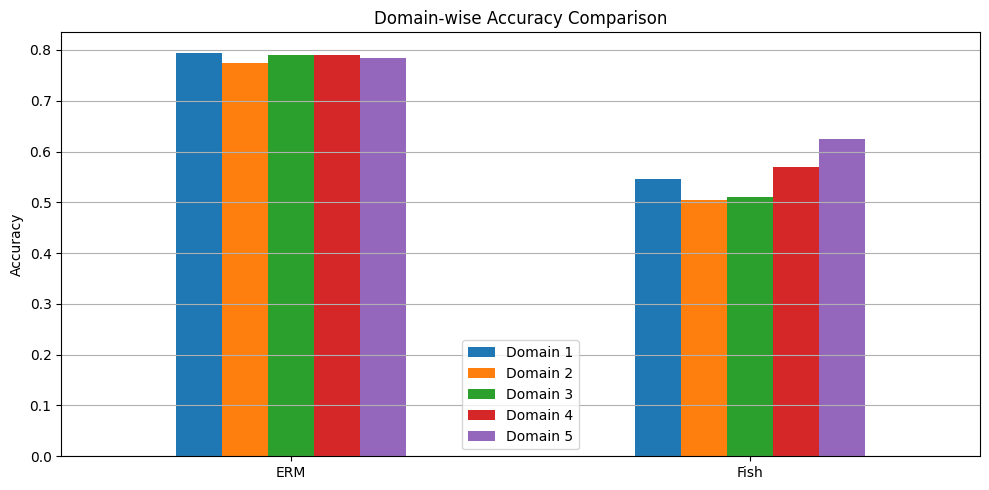

In [17]:
import pandas as pd
# 결과 시각화
pd.DataFrame({"ERM": acc_erm, "Fish": acc_fish}, index=[f"Domain {i+1}" for i in range(5)]).T.plot(kind="bar", figsize=(10, 5), ylabel="Accuracy", title="Domain-wise Accuracy Comparison", legend=True)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [18]:
# Fish 학습 및 평가
model_fish = ClassificationMLP()
criterion_fish = nn.BCEWithLogitsLoss()
train_fish(model_fish, train_domains, criterion_fish, penalty_weight=0.01)
acc_fish = evaluate_accuracy(model_fish, classification_data, "Fish")
print("Fish acc_erm", acc_fish)


Fish | Domain 1: Accuracy = 0.7400
Fish | Domain 2: Accuracy = 0.5800
Fish | Domain 3: Accuracy = 0.5100
Fish | Domain 4: Accuracy = 0.4950
Fish | Domain 5: Accuracy = 0.4950
Fish acc_erm [0.7400000095367432, 0.5799999833106995, 0.5099999904632568, 0.4950000047683716, 0.4950000047683716]


In [19]:
# Fish 학습 및 평가
model_fish = ClassificationMLP()
criterion_fish = nn.BCEWithLogitsLoss()
train_fish(model_fish, train_domains, criterion_fish, penalty_weight=0.01)
acc_fish = evaluate_accuracy(model_fish, classification_data, "Fish")
print("Fish acc_erm", acc_fish)


Fish | Domain 1: Accuracy = 0.8000
Fish | Domain 2: Accuracy = 0.7900
Fish | Domain 3: Accuracy = 0.7950
Fish | Domain 4: Accuracy = 0.8000
Fish | Domain 5: Accuracy = 0.7950
Fish acc_erm [0.800000011920929, 0.7900000214576721, 0.7950000166893005, 0.800000011920929, 0.7950000166893005]


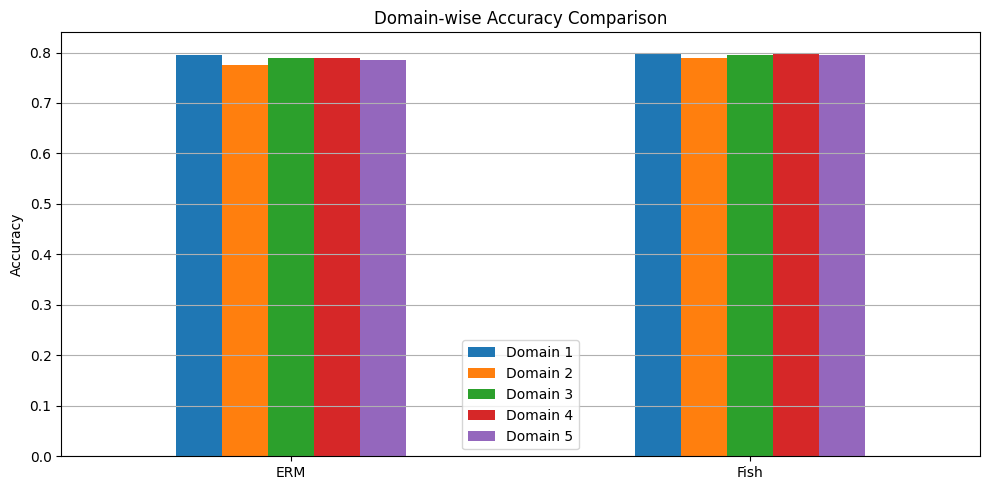

In [20]:
import pandas as pd
# 결과 시각화
pd.DataFrame({"ERM": acc_erm, "Fish": acc_fish}, index=[f"Domain {i+1}" for i in range(5)]).T.plot(kind="bar", figsize=(10, 5), ylabel="Accuracy", title="Domain-wise Accuracy Comparison", legend=True)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
